# Итоговое домашнее задание
## Современные методы анализа данных
`PS_2026.06.25_09.28.45.csv` - файл содержит информацию о экзопланетах и коричневых карликах. 

Данные взяты с сайта NASA Exoplanet Archive https://exoplanetarchive.ipac.caltech.edu/index.html.

Обозначения колонок:

`pl_name` - название планеты

`sy_snum` - кол-во звёзд в звёздной системе планеты

`discoverymethod` - метод открытия

1. Транзит (Transit) 
Суть: планета проходит по диску звезды, слегка затмевая её свет. Если изменения потока света звезды переодичны, у неё может быть планета.

Характеристики, которые можно найти:
* Период обращения.
* Радиус планеты (что важно в этой работе).
* Состав атмосферы (если спектр хороший).  
* Нельзя узнать массу (что тоже важно для этой работы)

2. Радиальная скорость (Radial Velocity) 

Суть: планета притягивает звезду своей массой, и та раскачивается вокруг положения равновесия. Спектрометр видит смещение линий спектра за счет эффекта Допплера.

Характеристики:
* Минимальная масса (точнее — произведение массы на синус угла наклона орбиты).
* Орбитальный период.
* Эксцентриситет орбиты.
* Нельзя найти размер.

3. Прямое наблюдение (Imaging) 

Суть: камера телескопа непосредственно видит пятно света рядом со звездой.

Характеристики:
* Расстояние от звезды.
* Температура и состав атмосферы (если яркое тело).

4. Вариация времени транзитов (Transit Timing Variations) 

Суть: соседняя планета своим притяжением сдвигает время прохождения первой планеты мимо звезды.

Характеристики:
* Наличие соседних планет.
* Массы обеих планет (если известна орбита).

5. Модуляция яркости (Orbital Brightness Modulation) 

Суть: планета отражается светом звезды, и телескоп замечает колебания общего блеска системы.

Характеристики:
* Эффективная площадь отражающей поверхности.
* Угол фаз (позиция планеты на орбите).  

`disc_year` - год открытия

`pl_radj` - радиус планеты в радиусах Юпитера

`pl_bmassj`- масса в массах Юпитера или масса умноженная на $\sin(i)$, где $i$-угол наклона орбиты планеты

`pl_controv_flag` - значения, которые показывают статус планет (кандидат или подтвержденная планета). 

`soltype` - флаг указывающий на то, подвергается ли сомнению статус планеты

Данные подобраны так, чтобы все планеты были подтвержденны. Также сделано так, чтобы у каждой планеты были определены масса и размер. Так как методы изучения не могут дать данные о размерах и массах экзопланет одновременно это означает, что каждая планета изучалась несколькими методами (обычно это метод радиальных скоростей и транзитный метод).

Цели: 

* проанализировать как менялось количество открытых планет с годами

* проанализировать отношение планет в двойных и одиночных системах

* проанализировать по методу открытия

* найти зависимость размера планеты от ее массы 



In [24]:
import numpy as np #Подключим нужные библиотеки и посмотрим как выглядит датасет
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('PS_2026.06.25_09.39.08.csv', skiprows=20)
#В csv описано, что означает каждый столбик, поэтому пропускаем эти строчки
data.sample(5)

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
3189,K2-229 b,1,Transit,2018.0,Published Confirmed,0,0.106789,0.007834
912,OGLE-TR-132 b,1,Transit,2004.0,Published Confirmed,0,1.150000,1.010000
655,HATS-77 b,1,Transit,2021.0,Published Confirmed,0,1.165000,1.374000
745,TOI-1601 b,1,Transit,2021.0,Published Confirmed,0,1.266754,1.217638
750,WASP-95 b,1,Transit,2014.0,Published Confirmed,0,1.210000,1.204000


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          3381 non-null   object 
 1   sy_snum          3381 non-null   int64  
 2   discoverymethod  3381 non-null   object 
 3   disc_year        3380 non-null   float64
 4   soltype          3381 non-null   object 
 5   pl_controv_flag  3381 non-null   int64  
 6   pl_radj          3381 non-null   float64
 7   pl_bmassj        3381 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 211.4+ KB


Видим,что в `disc_year` есть пропущеное значение

In [26]:
missing_rows = data[data.isnull().any(axis=1)]# ищем пропущенные значения
missing_rows

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
2918,TOI-5789 c,1,Transit,NaN,Published Confirmed,0,0.255153,0.015732


По названию планеты на сайте ищем что с ней не так
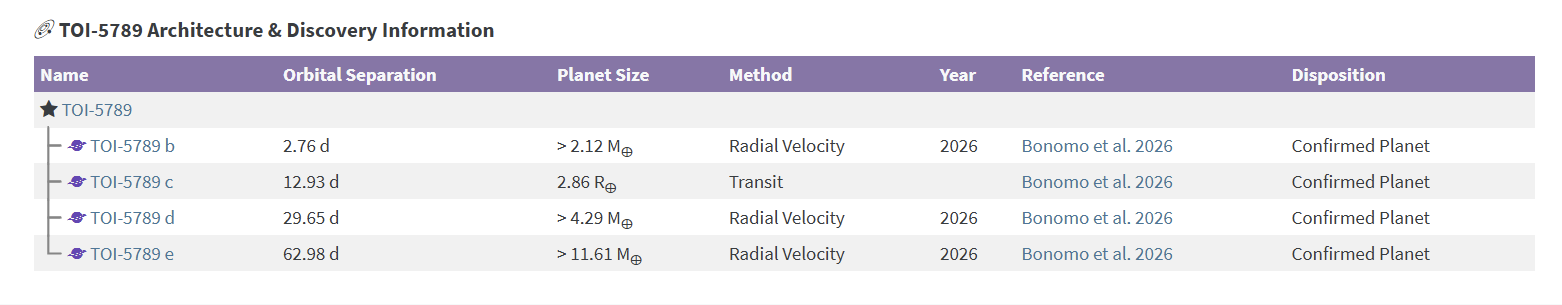
Препринт опубликован за 2026 год. Давайте такой год и поставим для этой планеты

In [27]:
data_copy=data.copy()
data_copy.loc[data['pl_name'] == 'TOI-5789 c', 'disc_year'] = 2026.0
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          3381 non-null   object 
 1   sy_snum          3381 non-null   int64  
 2   discoverymethod  3381 non-null   object 
 3   disc_year        3381 non-null   float64
 4   soltype          3381 non-null   object 
 5   pl_controv_flag  3381 non-null   int64  
 6   pl_radj          3381 non-null   float64
 7   pl_bmassj        3381 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 211.4+ KB


In [28]:
pl_name_counts = data_copy['pl_name'].value_counts() # проблема: некоторые планеты упоминаются в разных статьях
pl_name_counts.head(5)

TrES-2 b       16
HD 209458 b    11
WASP-4 b       11
Kepler-10 b    10
WASP-18 b      10
Name: pl_name, dtype: int64

In [29]:
data_copy[data_copy['pl_name'] == 'K2-3 d']

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
2373,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.136497,0.034924
2658,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.135605,0.023598
3170,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.135606,0.008810
3221,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.130074,0.006922
3272,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.147203,0.005663
3291,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.144527,0.005034


Для каждой планеты должны быть уникальные значения массы и радиуса. В данных же мы видим, что некоторые планеты повторяются с разными значениями этих параметров. Это связано с тем, что по каждой планете могло быть несколько исследований с разными результатами.

Для простоты расчетов и уменьшения влияния выбросов значений на данные будем просто брать медианные значения радиуса и массы.

In [30]:
cleaned_df = (
    data_copy.groupby('pl_name')
    .agg({
        'sy_snum': 'first',
        'discoverymethod': 'first',
        'disc_year': 'first',  
# Столбцы выше не должны меняться. Столбцы с флагом и статусом убрал, т.к. они больше не нужны
        'pl_radj': 'median',  
        'pl_bmassj': 'median'
    })
    .reset_index()
)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1680 non-null   object 
 1   sy_snum          1680 non-null   int64  
 2   discoverymethod  1680 non-null   object 
 3   disc_year        1680 non-null   float64
 4   pl_radj          1680 non-null   float64
 5   pl_bmassj        1680 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 78.9+ KB


In [31]:
cleaned_df['sy_snum'].value_counts() #сколько звёзд в стстеме

1    1422
2     222
3      35
4       1
Name: sy_snum, dtype: int64

Считается, что количество одинарных и двойных звёзд примерно равно (https://ru.wikipedia.org/wiki?curid=8610527).

Но в наших данных получилось, что число планет у одиночных систем почти в 7 раз больше. Это может быть связано как и с гравитационной нестабильностью систем с несколькими звёздами, так и с особенностями отбора данных. Методы поиска экзопланет (например, транзитный или метод лучевых скоростей) хуже работают в двойных системах из-за наложения световых сигналов и сложных орбит.

In [32]:
cleaned_df['discoverymethod'].value_counts() #каким образом открыли

Transit                          1603
Imaging                            36
Radial Velocity                    31
Transit Timing Variations           9
Orbital Brightness Modulation       1
Name: discoverymethod, dtype: int64

Подавляющее число планет в датафрейме открыто транзитным методом. Это является следствием специфической выборки. Если бы мы не выбирали планеты где известна и масса и радиус отношение планет открытых транзитным методом к методу радиальных скоростей было бы 3:1

In [33]:
cleaned_df.describe() #средние значения планет. большие отклонения - разные типы+

,sy_snum,disc_year,pl_radj,pl_bmassj
count,1680.000000,1680.000000,1680.000000,1680.000000
mean,1.175595,2017.829167,0.728596,1.268835
std,0.436019,5.204454,0.559151,3.151562
min,1.000000,1999.000000,0.027639,0.000205
25%,1.000000,2014.000000,0.218642,0.029812
50%,1.000000,2018.000000,0.656250,0.221000
75%,1.000000,2023.000000,1.167250,1.037750
max,4.000000,2026.000000,7.780000,30.000000


Видим, что средний радиус и средняя масса планет близки к массе Юпитера. Максимальное значение массы 30, что соответствует классу Коричневых карликов - промежуточному объекту между планетами и звездами. При анализе отношения массы/радиуса нужно будет учитывать что не все объекты в датафрейме это планеты.

Кроме всего, можно отметить, что стандартное отклонение для радиусов планет очень большое. Почему так получилось будет объяснено ниже.

In [34]:
cleaned_df.groupby('sy_snum')['pl_bmassj'].describe()

,count,mean,std,min,25%,50%,75%,max
sy_snum,,,,,,,,
1,1422.0,1.280592,3.293002,0.000205,0.028396,0.185792,0.978625,30.000000
2,222.0,1.123958,2.064833,0.000913,0.046940,0.523500,1.171000,14.004987
3,35.0,1.731154,3.030014,0.000315,0.018862,0.530000,1.520000,12.370000
4,1.0,0.531000,NaN,0.531000,0.531000,0.531000,0.531000,0.531000


В датасете только одна система с 4 звездами, поэтому делать на основании её какие-то выводы (кроме того, что такие системы существуют) мы не будем. Видим, что планеты в двойных и тройных системах в средним имеют больший вес. Это объяснеется методом отбора данных. Чем выше отношение массы планеты к массе звезды (или звезд) вокруг которых она вращается тем проще ее обнаружить. Это обясняет рост значений для множественных систем.

Рассмотрим какое кол-во планет находили в разные годы.

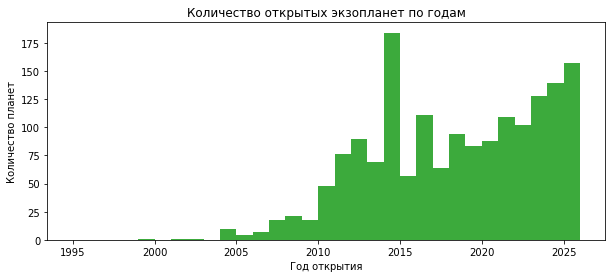

In [35]:
years = cleaned_df['disc_year'].dropna().round().astype(int)
ax = years.plot.hist(bins=range(1995, 2027), figsize=(10, 4), color='#3caa3c')
# Окрашиваем столбцы в цвет влюбленной жабы - #3caa3c, чтобы было веселее.
ax.set_title('Количество открытых экзопланет по годам')
ax.set_ylabel('Количество планет')
ax.set_xlabel('Год открытия');

Начало роста числа найденых планет 2010 год - год запуска телескопа "Кеплер", который был запущен для поиска экзопланет транзитным методом.

Резкий скачек в 2014 - комманда "Кеплера" модифицировала методику проверки данных и обнаружила разом порядка 2000 планет.

Скачек в 2018 - запуск телескопа TESS.

Рассмотрим есть ли отличия в характиристиках планет взависимости от того, сколько звёзд в системе. Сравнивать будем одинарные (число солнц в системе == 1) и множественные (звёзд>1). Построим графики плотности распределения планет по массам и размерам.

In [36]:
single_star = cleaned_df.query("sy_snum == 1")
multiple_star = cleaned_df.query("sy_snum >1")

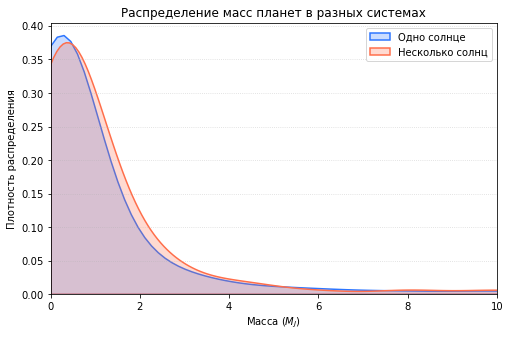

In [37]:
common_params = dict(
    cut=0,          # Плотность не уходит в минус
    clip=(0, None),   # Диапазон масс
    fill=True,
    linewidth=1.5,
    common_norm=False  # Отдельная нормировка для каждого слоя
)

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=single_star,
    x="pl_bmassj",
    label="Одно солнце",
    color="#2c75ff", #Цвет Электрик 
    **common_params
)

sns.kdeplot(
    data=multiple_star,
    x="pl_bmassj",
    label="Несколько солнц",
    color="#FF6E4A",  #Цвет Скандально оранжевый 
    **common_params
)


plt.title("Распределение масс планет в разных системах")
plt.xlabel("Масса ($M_J$)")
plt.ylabel("Плотность распределения")
plt.xlim(0, 10)
#plt.ylim(0, 0.01)
plt.grid(axis="y", linestyle=":", alpha=0.5)

plt.legend(title="", loc="best")

plt.show()

Распределения планет по массам практически идентичны для одинарныхи множественных систем. Оба распределения выглядят как смещенные нормальные распределения. Пик для множественных систем чуть правее, что наблюдали в статистических данных

Теперь посмотрим как выглядит плотность распределения по размерам планет

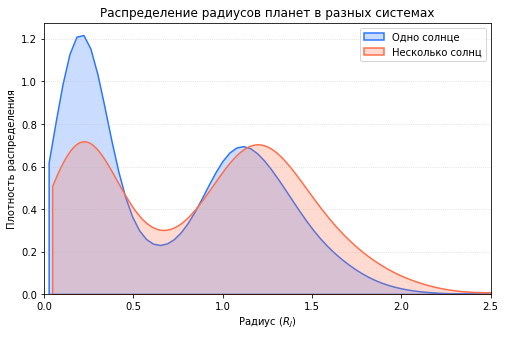

In [38]:
common_params = dict(
    cut=0,
    clip=(0, None),  # Диапазон радиусов
    fill=True,
    linewidth=1.5,
    common_norm=False  # Отдельная нормировка для слоев
)

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=single_star,
    x="pl_radj",
    label="Одно солнце",
    color="#2c75ff", #Цвет Электрик 
    **common_params
)

sns.kdeplot(
    data=multiple_star,
    x="pl_radj",
    label="Несколько солнц",
    color="#FF6E4A",  #Цвет Скандально оранжевый 
    **common_params
)

# Оформление
plt.title("Распределение радиусов планет в разных системах")
plt.xlabel("Радиус ($R_J$)")
plt.ylabel("Плотность распределения")
plt.xlim(0.0, 2.5)
#plt.ylim(0, 0.01)
plt.grid(axis="y", linestyle=":", alpha=0.5)

# Легенда
plt.legend(title="", loc="best")
plt.show()

Видим, что оба распределения имеют два пика: 0.2 и 1.1-1.2 $R_J$. Это может объяснить большие значения стандартного отклонения.

0.2 $R_J$ - приблизительный размер суперземель.

1.1-1.2 $R_J$ - критический размер планет гигантов. Начиная примерно с 1 $M_J$ должны начинаться термоядерные реакции внутри ядра планеты. Из-за этого дальнейшее увеличение массы практически не даёт рост размера объекта. Таким образом второй пик обусловлен тем, что все объекты массой большей, чем масса Юпитера (приблезительно) будут иметь практически одинаковый размер.

По распределениям можно сделать вывод, что суперземли чаще находятся у одиночных систем.

Теперь построим зависимость радиуса планет от их массы. 

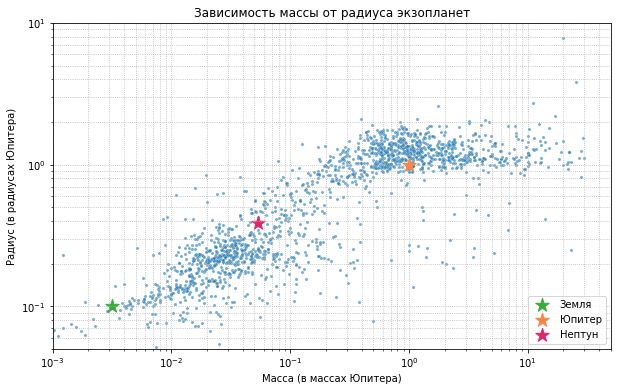

In [39]:
solar_system = {
    'Земля': {'mass': 0.00315, 'radius': 0.101, 'color': '#3caa3c'}, #Цвет влюбленной жабы
    'Юпитер': {'mass': 1.0, 'radius': 1.0, 'color': '#ff8243'}, #Цвет Манго-танго
    'Нептун': {'mass': 0.054, 'radius': 0.388, 'color': '#e3256b'} #Цвет суеты
}
clean_plot = cleaned_df.copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_plot,
    x='pl_bmassj', y='pl_radj',
    alpha=0.6, s=10
)
for planet, params in solar_system.items():
    plt.scatter(params['mass'], params['radius'],
               color=params['color'], marker='*', s=200, label=planet)

plt.xscale('log'); plt.yscale('log')
plt.xlim(1e-3, 50)
plt.ylim(5e-2, 10)
plt.grid(True, which='both', ls=':')
plt.title('Зависимость массы от радиуса экзопланет')
plt.xlabel('Масса (в массах Юпитера)')
plt.ylabel('Радиус (в радиусах Юпитера)')
plt.legend(loc='lower right', framealpha=0.8)
plt.show()

Видим, что для объектов, чья масса меньше массы Юпитера примерно в половину зависимость $M \sim R^\alpha$ (почти линейная на графике log). Это логично: масса пропорциональна объёму тела, а объем тела кубу его размера. В реальности $\alpha<3$ по нескольким причинам:
* Многие из обнаруженных планет - газовые гиганты, а значит их плотность будет ниже, а масса всё равно большой из-за тяжелого плотного ядра
* Вещество в недрах планет может сжимается силами гравитации и формула $M \sim R^\alpha$ становится не применима. Именно из-за этого эффекта график выходит на плато для объектов, чья масса больше массы Юпитера. Размеры коричневых карликов практически не меняются при росте массы
* Определение масс планет с помощью Допплер-эффекта дает оценку с точностью до $\sin(i)$, что связано с недостатками рассчетов самого метода
* Транзитный метод может давать большие погрешности для маленьких планет. Появления звёздных пятен и вспышек будут давать дополнительные шумы.

Кроме того заметно, что есть два кластера планет: планеты с массами порядка массы Юпитера (газовые гиганты) и с массами от массы Земли до массы Нептуна (суперземли).

Причина появления этих кластеров - селекция данных. Методами транзита проще исследовать близкие к звездам планеты, а методом радиальных скоростей - массивные. Планеты с массамы больше массы Нептуна это газовые гиганты находящиеся близко к своей звезде. Они нестабильны, так как их массы недостаточно для удержания атмосферы. Суперземли - каменные планеты и такой проблемы для них нет.


# Вывод

В ходе работы был проведён анализ экзопланет и коричневых карликов по данным NASA. Основные результаты:в

* Число обнаруженных планет резко увеличилось после 2010 года благодаря запуску телескопа «Кеплер» и миссии TESS. Большинство объектов найдено транзитным методом.
* В выборке преобладают планеты у одиночных звёзд, так как методы поиска хуже работают во множественных системах из-за наложения сигналов. При этом планеты в кратных системах в среднем массивнее.
* Для планет легче Юпитера зависимость массы от радиуса близка к степенной. У массивных объектов (включая коричневые карлики) размер выходит на плато и почти не растёт с массой.
* Можно четко проследить, что большая часть открытых планет относится к одному из двух классов: суперземли и планеты гиганты. В одиночных системах суперземли находят чаще.
* Выборка смещена в сторону массивных планет и суперземель, так как для их определения одновременно используются транзитный метод и метод лучевых скоростей.

**Что можно было бы добавить для улучшения работы**
* Для изучения как меняется размер космических объектов от их массы можно было бы добавить данные о звёздах, например из следующего датасета
https://www.kaggle.com/datasets/devendrasingh22/astronomical-data/data
 При этом масса звёзд высчитывалась бы исходя из её класса по теоретической формуле зависимости спектра-светимости. В теории, для звёзд вновь должен появиться рост размера от массы. Кроме того, можно было бы лучше разглядеть плато коричневых карликов, т.к. в новом датасете они тоже присутствуют.
* Существует мнение, что суперземли и маленькие планеты чаще находят у звёзд типа - красный карлик. Это можно было бы проверить совместив датасет по ссылке выше и добавив данные о звезде, вокруг которой обращается планета, в текущий датасет. Сейчас, если объединять данные о звезде с сайта NASA с этим датасетом куда-то исчезает половина планет. Это связано с тем как информация представлена в базе NASA, но как это исправить пока не знаю. Ниже код, который показывает в чем проблема.



<span style="font-family: 'Comic Sans MS', cursive;">Далее идет душное объяснение, почему улучшить работу через добавление дополнительного набора данных не вышло.</span> 

<span style="font-family: 'Comic Sans MS', cursive;">Если я успею, я уберу душное объяснение и добавлю что-то толковое, но пока чего-то важного или интересного после шрифта Sans нет(</span>



In [40]:
cleaned_df.info()#Наш итоговый датафрейм. Число планет 1680

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1680 non-null   object 
 1   sy_snum          1680 non-null   int64  
 2   discoverymethod  1680 non-null   object 
 3   disc_year        1680 non-null   float64
 4   pl_radj          1680 non-null   float64
 5   pl_bmassj        1680 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 78.9+ KB


In [41]:
dataRM=cleaned_df.copy() #копия датафрейма с массами и размерами планет, для дальнейшей работы 
data = pd.read_csv('dopPS_2026.07.01_06.54.44.csv', skiprows=15) 
#Скачиваем новый датафрейм с данными о имени планеты, звезды и её спектрального класса
result_df = (
    data.groupby('pl_name')
    .agg({
        'sy_snum': 'first',     
        'hostname': 'first',
        'st_spectype': 'first'
    })
    .reset_index()# Группируем по планетам. 
)
dataS = result_df.dropna()
merged_df = dataRM.merge(dataS, on='pl_name', how='inner')# объединяем по столбику с планетами
merged_df.info()#число планет в датафрейме сократилось 1680->869


<class 'pandas.core.frame.DataFrame'>
Int64Index: 869 entries, 0 to 868
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          869 non-null    object 
 1   sy_snum_x        869 non-null    int64  
 2   discoverymethod  869 non-null    object 
 3   disc_year        869 non-null    float64
 4   pl_radj          869 non-null    float64
 5   pl_bmassj        869 non-null    float64
 6   sy_snum_y        869 non-null    int64  
 7   hostname         869 non-null    object 
 8   st_spectype      869 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 67.9+ KB


В `dopPS_2026.07.01_06.54.44.csv` если у звезды несколько планет, название звезды и её класс указан только у ближайшей к своему Солнцу (название экзопланеты это название звезды + буква (`a,b,c...`. Например:`TOI-5789 c` это третья планета от звезды `TOI-5789`. т.е. ближайшая должна быть с индексом `a`. Проблема в том, что:
- индексом `a` обозначен ближайшей к звезде ОБЪЕКТ. Это может оказаться, НЕ ПЛАНЕТА: нейтронная звезда, черная дыра, какая-то относительно неяркая звезда  и т.д. И тогда она не попадет в базу. И тогда `.dropna()` ее удалит.
- планета могла иметь статус кандидата, потом её обнаружение опровергли.

Примером можно привести `2MASS J03590986+2009361 b`

In [42]:
data[data['pl_name'] == '2MASS J03590986+2009361 b']

,pl_name,hostname,sy_snum,soltype,pl_controv_flag,st_spectype
43,2MASS J03590986+2009361 b,2MASS J03590986+2009361,1,Published Confirmed,0,NaN


Известны характеристики звезды,вокруг которой обращается планета (можно посмотреть на этом сайте https://science.nasa.gov/exoplanet-catalog/2mass-j035909862009361-b/)
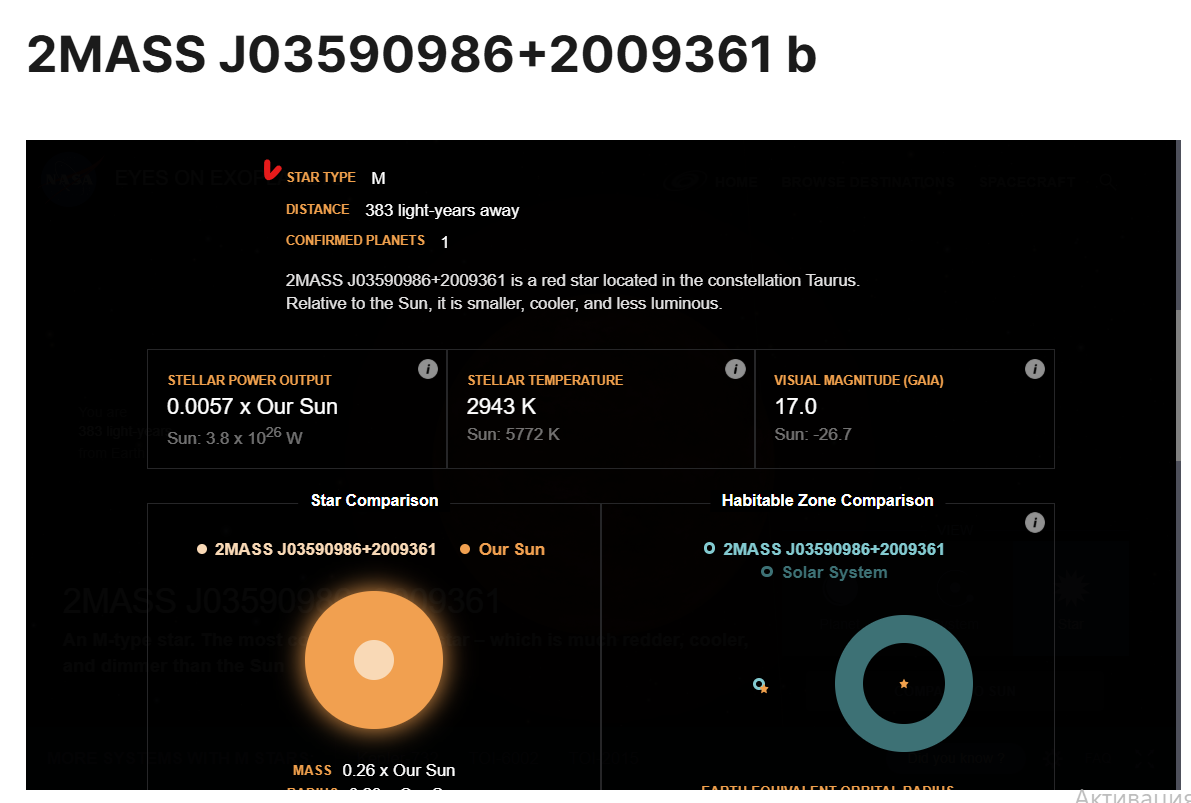


На сайте видно, что других объектов в солнечной системе звезды не обнаружено.

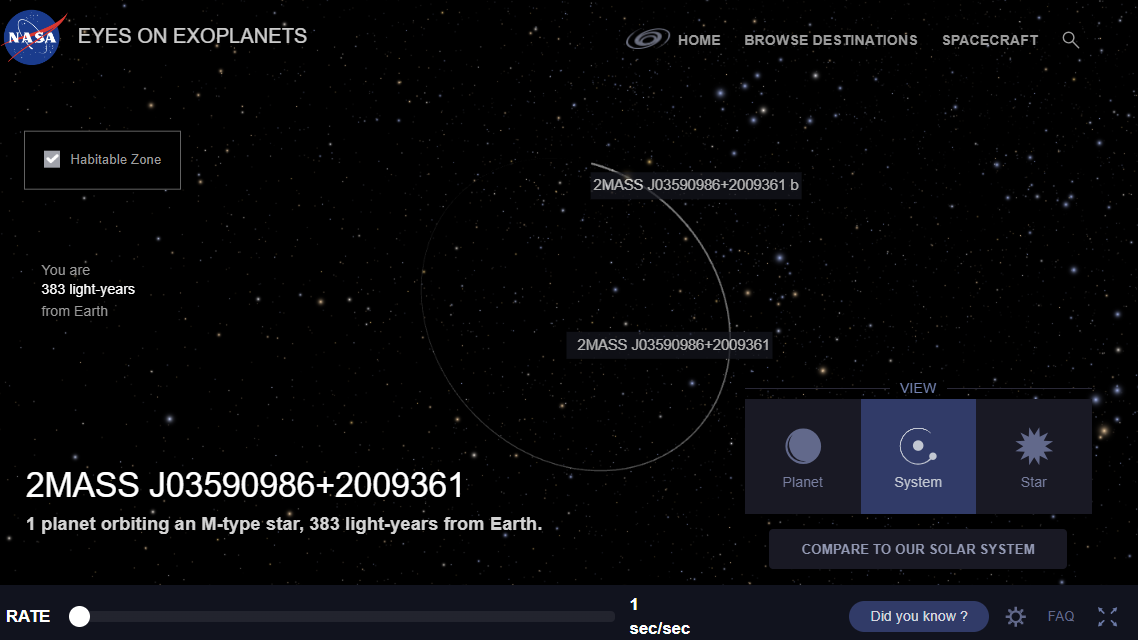

Но по базе данных о планете `st_spectype==NaN` (https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=STELLARHOSTS).
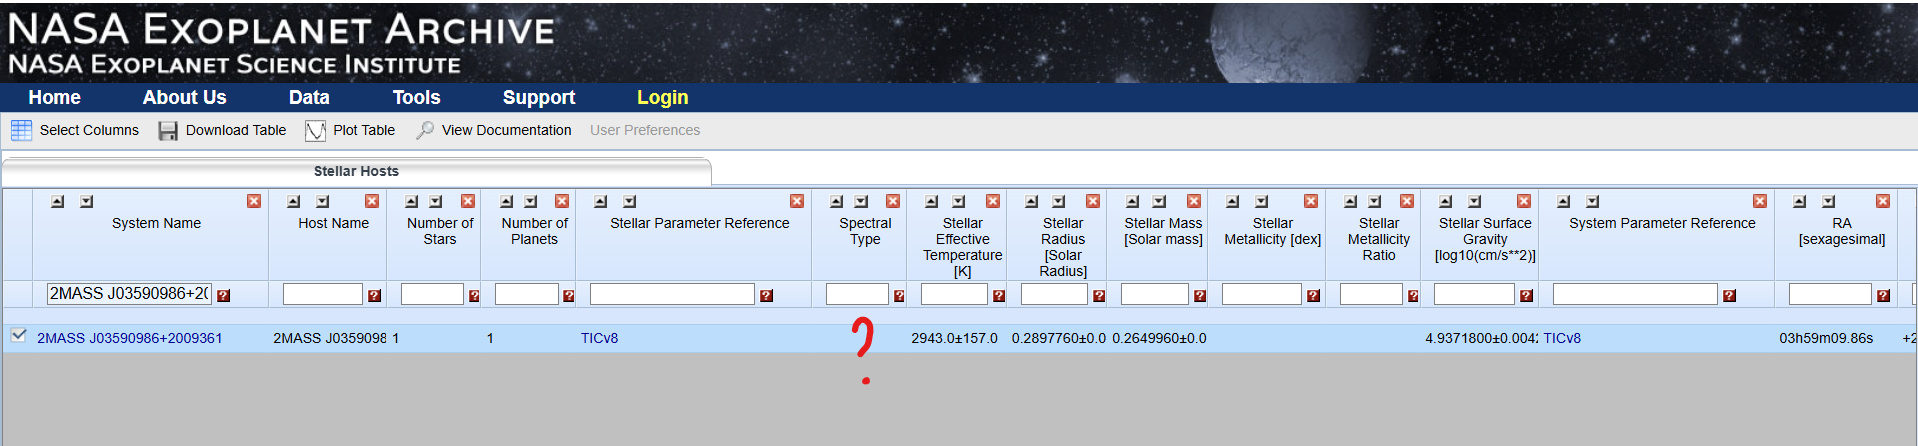

Почему так получилось, нужно разбираться. Я попробую это сделать, но уже, видимо, не к сроку выполнения(